# DAF-08 — First look: what is wrong with the raw data

There is now a working baseline model (DAF-07). From here, every change to
the data has to earn its place by moving the MAE. But nobody has actually
looked hard at R K Puram's raw sensor data to see what's broken in it — the
daily table (`daily_17.csv`) was built by aggregating 15-minute readings into
daily means mechanically, without eyes on what was being aggregated.

This ticket is a pure investigation: look, measure, and write down every
fault, each with evidence (a count, a percentage, or a plot). **Nothing gets
fixed here** — that's DAF-09, on purpose.

**Why split "find" from "fix"?** If you fix as you notice things, you end up
with an undocumented pile of judgment calls baked into the pipeline — months
from now you won't remember *why* you dropped three days in July, or capped
values at 500, or interpolated a gap. Writing `docs/data_faults.md` first
means each fix in DAF-09 becomes a traceable decision: fault, evidence,
chosen treatment, reason.

**What gets checked** (the ticket's background table):

| Where to look | Question to ask |
|---|---|
| The four 15-min readings inside one hour | Are they independent measurements? |
| The biggest values | Is the largest reading plausible for Delhi air? What happened that day? |
| Missing hours and missing days | Random, or in blocks? Which months? |
| The invalid days from DAF-05 | Spread out, or clustered? |
| The other `parameter` values in the raw files | What else does this station measure, and could it help a forecast? |
| `sensors_id` | Exactly one PM2.5 sensor across the whole span? |

**Deliverable:** `docs/data_faults.md` — one row per fault, with evidence,
row count affected, and at least two possible treatments (options, not a
decision).

---

## Step 1 — Load, don't touch

This notebook only *looks and measures*. Nothing here changes a file under
`data/`.

We read from two places only:

- `data/raw/openaq/locationid=17/...` — the raw per-day OpenAQ files, gzipped
  CSV, one file per day, containing every 15-minute reading for every
  `parameter` this station reports (not just PM2.5).
- `data/interim/daily_17.csv` — the daily table already built in DAF-06/07
  (`pm25_mean`, `hours`, `pm25_until_17`, `valid`, `target`).

First cell: imports, and load `daily_17.csv` plus the list of raw files so we
know what span and how many files we're working with before measuring
anything.

In [1]:
import gzip
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = Path("../data/raw/openaq/locationid=17")
DAILY_PATH = Path("../data/interim/daily_17.csv")

daily = pd.read_csv(DAILY_PATH, parse_dates=["date"])
raw_files = sorted(RAW_DIR.glob("year=*/month=*/*.csv.gz"))

print(f"daily_17.csv: {len(daily)} rows, {daily['date'].min()} to {daily['date'].max()}")
print(f"raw files found: {len(raw_files)}")
raw_files[:3]

daily_17.csv: 571 rows, 2025-02-19 00:00:00+05:30 to 2026-09-12 00:00:00+05:30
raw files found: 554


[PosixPath('../data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250219.csv.gz'),
 PosixPath('../data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250220.csv.gz'),
 PosixPath('../data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250221.csv.gz')]

## Step 2 — Measure each fault

Loading all raw files once, as `pm25` rows only, so the rest of this step can
just slice and count instead of re-reading gzip files each time. This is the
one broad read of the raw data; every later check reuses `pm25_raw`.

### 2a — Are the four 15-minute readings inside one hour independent?

If a sensor is stuck or just repeating its last value, three of every four
15-minute readings in an hour would be identical (or near-identical) to the
one before them. We check this directly: for each hour, how many of its
15-min readings are exact duplicates of the previous reading in that hour?

In [2]:
def read_raw_file(path):
    with gzip.open(path, "rt") as f:
        return pd.read_csv(f, parse_dates=["datetime"])

frames = [read_raw_file(p) for p in raw_files]
raw_all = pd.concat(frames, ignore_index=True)

pm25_raw = raw_all[raw_all["parameter"] == "pm25"].copy()
pm25_raw = pm25_raw.sort_values("datetime").reset_index(drop=True)

print(f"raw_all: {len(raw_all)} rows across all parameters")
print(f"pm25_raw: {len(pm25_raw)} rows")
pm25_raw.head()

raw_all: 467816 rows across all parameters
pm25_raw: 44139 rows


,location_id,sensors_id,location,datetime,lat,lon,parameter,units,value
0,17,12234787,"R K Puram, Delhi - DPCC-3379481",2025-02-19 01:45:00+05:30,28.563262,77.186937,pm25,µg/m³,123.0
1,17,12234787,"R K Puram, Delhi - DPCC-3379481",2025-02-19 02:00:00+05:30,28.563262,77.186937,pm25,µg/m³,97.0
2,17,12234787,"R K Puram, Delhi - DPCC-3379481",2025-02-19 02:15:00+05:30,28.563262,77.186937,pm25,µg/m³,97.0
3,17,12234787,"R K Puram, Delhi - DPCC-3379481",2025-02-19 02:30:00+05:30,28.563262,77.186937,pm25,µg/m³,97.0
4,17,12234787,"R K Puram, Delhi - DPCC-3379481",2025-02-19 02:45:00+05:30,28.563262,77.186937,pm25,µg/m³,97.0


In [20]:
# Round each timestamp down to its hour, so all 4 readings in an hour
# (:00, :15, :30, :45) get grouped together under one label.
pm25_raw["hour"] = pm25_raw["datetime"].dt.floor("h")

print(list(pm25_raw.columns))

print(pm25_raw["value"])

# print("----------------------")

# print(pm25_raw["hour"])

# Within each hour, shift the value column down by one row.
# This lines up every reading with the reading that came right before it
# in the same hour (the first reading in an hour gets NaN, no "previous").
pm25_raw["prev_value"] = pm25_raw.groupby("hour")["value"].shift(1)


# True where a reading is exactly equal to the one before it in that hour.
# NaN == NaN is False, so the first reading of each hour is always False here.
pm25_raw["is_dup_of_prev"] = pm25_raw["value"] == pm25_raw["prev_value"]

# How many 15-min readings actually exist for each hour (should be 4 if none
# are missing).
readings_per_hour = pm25_raw.groupby("hour").size()

# For each hour, what fraction of its readings are duplicates of the one
# before them, e.g. 0.75 means 3 of 4 readings just repeated the prior value.
dup_share_per_hour = pm25_raw.groupby("hour")["is_dup_of_prev"].mean()

# Count of hours that have the full 4 readings, out of all hours seen.
print(f"hours with all 4 readings present: {(readings_per_hour == 4).sum()} / {len(readings_per_hour)}")

# Across every single reading, what share are duplicates of the previous
# reading in their hour, i.e. how "stuck" the sensor is overall.
print(f"share of readings that repeat the previous reading in the same hour: {pm25_raw['is_dup_of_prev'].mean():.2%}")

# Count of hours where the sensor was stuck almost the whole hour (>=99% of
# its readings after the first were duplicates).
print(f"hours where every reading after the first is a duplicate: {(dup_share_per_hour >= 0.99).sum()}")

['location_id', 'sensors_id', 'location', 'datetime', 'lat', 'lon', 'parameter', 'units', 'value', 'hour', 'prev_value', 'is_dup_of_prev', 'day', 'hour_of_day', 'month']
0        123.0
1         97.0
2         97.0
3         97.0
4         97.0
         ...  
44134     23.0
44135     23.0
44136     23.0
44137     23.0
44138     13.0
Name: value, Length: 44139, dtype: float64
hours with all 4 readings present: 9593 / 12165
share of readings that repeat the previous reading in the same hour: 68.66%
hours where every reading after the first is a duplicate: 0


### 2a — what the cell above actually does, as blocks

```text
pm25_raw (44,139 rows: one row per 15-min reading)
        │
        ▼
Round each datetime DOWN to its hour
  "hour" column: 01:45 -> 01:00, 02:00 -> 02:00, 02:15 -> 02:00 ...
        │
        ▼
Group rows by "hour", shift "value" down by 1 within each group
  "prev_value" = the value of the reading right before this one,
                 in the SAME hour (first reading of an hour -> NaN)
        │
        ▼
Compare value == prev_value
  "is_dup_of_prev" = True where a reading just repeats the last one
        │
        ├──────────────────────────────┬───────────────────────────┐
        ▼                               ▼                           ▼
group by "hour", count rows      group by "hour",            filter hours where
  -> readings_per_hour              mean("is_dup_of_prev")      dup_share >= 0.99
  (should be 4 if nothing            -> dup_share_per_hour       -> fully "stuck"
   is missing)                       (0.0 = all independent,      hours
        │                             1.0 = all duplicates)            │
        ▼                                   ▼                          ▼
"how many hours have               "overall, what %           "how many hours
 full 4/4 coverage?"                 of readings just           are stuck for
                                      repeat the last            their entire
                                      one?"                      span?"
```

**In one line:** load every 15-min reading → tag it with its hour → compare
each reading to the one before it in that hour → count how often that
comparison is "same value" (duplicate) vs "different value" (real
measurement).

### 2a — one day only, before the full dataset

Before trusting the whole-dataset numbers (68.66% duplicate rate), look at
one real day and see the actual values. If the pattern is obvious in one
day, the aggregate number stops being an abstract statistic and becomes
something we can explain.

We isolate `2025-02-19` — the very first day in the raw data — and rebuild
the same three columns (`hour`, `prev_value`, `is_dup_of_prev`) on just that
slice, then print every row and plot it.

**What is `prev_value`?**

For every reading, `prev_value` just means "the value of the reading right
before this one, in the same hour." It's not the hour's average or anything
computed — it's literally the row above it.

**Important: `prev_value` is `NaN` once per hour, not once for the whole
day.** `groupby("hour")` splits the day into 24 separate little groups
(`01:00`, `02:00`, `03:00`, ...) and the "slide down by one row" only happens
*within* each group. So every group's first row has nothing above it inside
that group, and gets `NaN` — even though, looking at the full table, that row
isn't the first row overall. Across one day you'll see roughly 24 `NaN`s, one
per hour, not just one.

Example — two different hours from `2025-02-19`, both starting with `NaN`:

| datetime | hour | value | prev_value | why |
|---|---|---|---|---|
| 01:45 | **01:00** | 123.0 | NaN | first (only) reading in the `01:00` group |
| 02:00 | **02:00** | 97.0 | NaN | first reading in the `02:00` group — a *different* group, so it resets |
| 02:15 | 02:00 | 97.0 | 97.0 | copied from the 02:00 row above, same group |
| 02:30 | 02:00 | 97.0 | 97.0 | copied from the 02:15 row above, same group |
| 02:45 | 02:00 | 97.0 | 97.0 | copied from the 02:30 row above, same group |

We get this with one line: `groupby("hour")["value"].shift(1)` — "inside
each hour group, slide the value column down by one row." Pandas resets the
shift at the start of every group.

**What is `is_dup_of_prev`?**

Just a yes/no check: *does this reading's value equal the one right before
it (in the same hour)?* `is_dup_of_prev = (value == prev_value)`.

- Any row where `prev_value` is `NaN` → **False** (NaN never equals
  anything, so the first reading of *every* hour is always marked "not a
  duplicate," which is correct — it has nothing to duplicate)
- Any row where `value` matches the row above it → **True**, it's a
  duplicate

So a typical hour reads `[False, True, True, True]` — one real reading, then
three copies of it, then the pattern resets at the next hour. That's the
whole mechanism behind the green/orange plot below: green = `False`
(fresh, one per hour), orange = `True` (duplicate).

In [21]:
# Slice out just one day's readings from pm25_raw.
one_day = pm25_raw[pm25_raw["day"] == "2025-02-19"].copy()
one_day = one_day.sort_values("datetime").reset_index(drop=True)

print(f"{len(one_day)} readings on 2025-02-19 (out of a possible 24 x 4 = 96)")
one_day[["datetime", "hour", "value", "prev_value", "is_dup_of_prev"]]

88 readings on 2025-02-19 (out of a possible 24 x 4 = 96)


,datetime,hour,value,prev_value,is_dup_of_prev
0,2025-02-19 01:45:00+05:30,2025-02-19 01:00:00+05:30,123.0,NaN,False
1,2025-02-19 02:00:00+05:30,2025-02-19 02:00:00+05:30,97.0,NaN,False
2,2025-02-19 02:15:00+05:30,2025-02-19 02:00:00+05:30,97.0,97.0,True
3,2025-02-19 02:30:00+05:30,2025-02-19 02:00:00+05:30,97.0,97.0,True
4,2025-02-19 02:45:00+05:30,2025-02-19 02:00:00+05:30,97.0,97.0,True
...,...,...,...,...,...
83,2025-02-19 22:45:00+05:30,2025-02-19 22:00:00+05:30,106.0,106.0,True
84,2025-02-19 23:00:00+05:30,2025-02-19 23:00:00+05:30,75.0,NaN,False
85,2025-02-19 23:15:00+05:30,2025-02-19 23:00:00+05:30,75.0,75.0,True
86,2025-02-19 23:30:00+05:30,2025-02-19 23:00:00+05:30,75.0,75.0,True


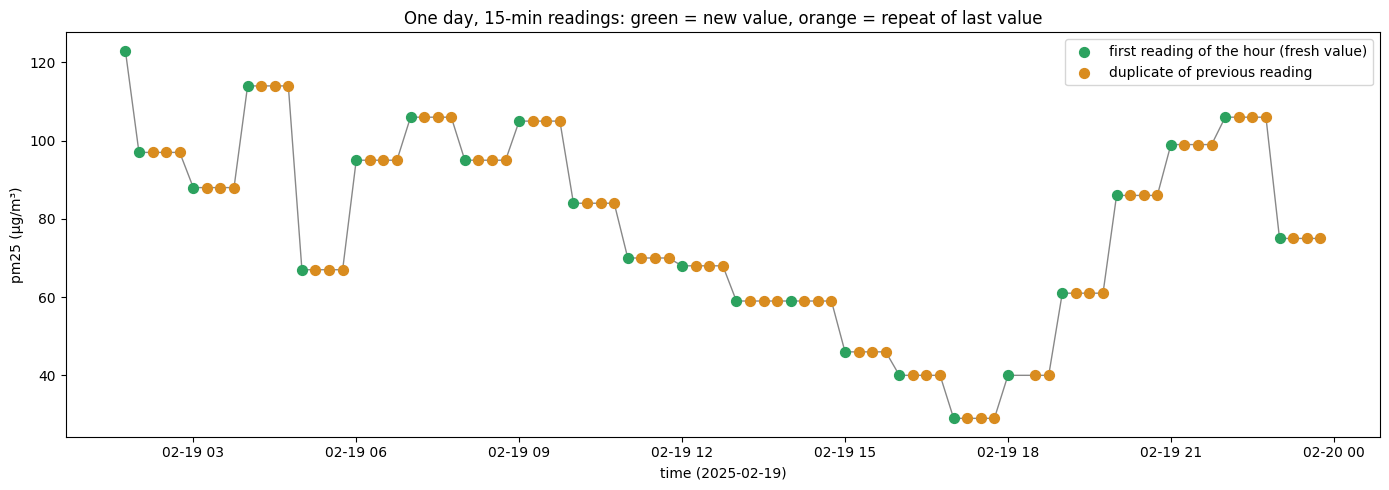

fresh readings: 23, duplicate readings: 65


In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

# The full 15-min line, so the step pattern (flat for 3 readings, jump, flat
# again) is visible.
ax.plot(one_day["datetime"], one_day["value"], color="#888", linewidth=1, zorder=1)

# Mark the first reading of each hour (the real, fresh value) in one colour...
first_of_hour = one_day[~one_day["is_dup_of_prev"]]
ax.scatter(first_of_hour["datetime"], first_of_hour["value"], color="#2ca25f",
           label="first reading of the hour (fresh value)", zorder=2, s=50)

# ...and every reading that just repeats the one before it, in another.
duplicates = one_day[one_day["is_dup_of_prev"]]
ax.scatter(duplicates["datetime"], duplicates["value"], color="#d98c1f",
           label="duplicate of previous reading", zorder=2, s=50)

ax.set_xlabel("time (2025-02-19)")
ax.set_ylabel("pm25 (µg/m³)")
ax.set_title("One day, 15-min readings: green = new value, orange = repeat of last value")
ax.legend()
plt.tight_layout()
plt.show()

print(f"fresh readings: {len(first_of_hour)}, duplicate readings: {len(duplicates)}")

### 2b — The biggest values

From the ticket: *"Is the largest reading plausible for Delhi air? What was
happening that day?"* We don't get to just call every huge number an error —
Delhi genuinely reaches values that look impossible elsewhere. Evidence
first, verdict later.

Since we now know each hour only has one real (fresh) value, we build an
`hourly` series by keeping the **first** reading of each hour — that removes
the duplicate padding and gives one true value per hour, exactly what we
need for this check.

Then: plot the whole span so the top-10 spikes are visible in context, list
the 10 biggest hourly values with their timestamps, and zoom into the week
around the single largest one to see its shape — a single-hour glitch looks
different from a multi-day pollution event.

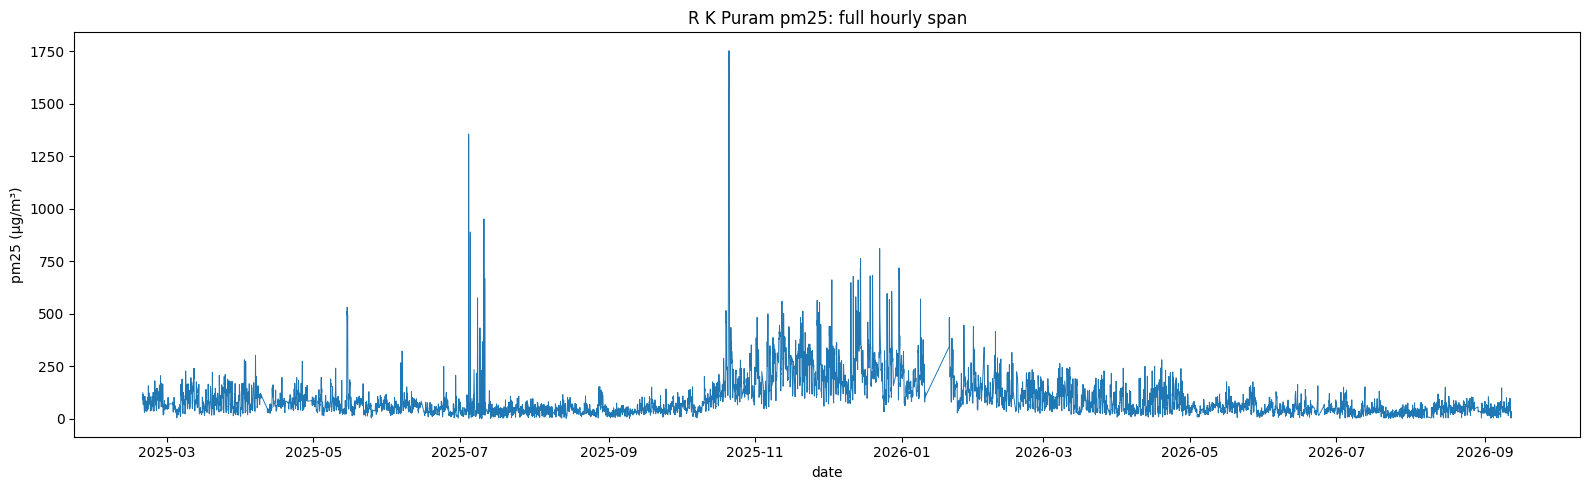

10 largest hourly values:


hour
2025-10-21 03:00:00+05:30    1753.0
2025-10-21 04:00:00+05:30    1656.0
2025-10-21 05:00:00+05:30    1602.0
2025-10-21 00:00:00+05:30    1476.0
2025-07-04 17:00:00+05:30    1356.0
2025-07-04 18:00:00+05:30    1316.0
2025-10-20 23:00:00+05:30    1267.0
2025-10-21 06:00:00+05:30    1187.0
2025-10-21 07:00:00+05:30    1064.0
2025-07-11 02:00:00+05:30     951.0
Name: value, dtype: float64

In [23]:
# Keep only the first (fresh) reading of each hour -> one true value per hour.
hourly = pm25_raw.groupby("hour")["value"].first()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(hourly.index, hourly.values, linewidth=0.7)
ax.set_xlabel("date")
ax.set_ylabel("pm25 (µg/m³)")
ax.set_title("R K Puram pm25: full hourly span")
plt.tight_layout()
plt.show()

print("10 largest hourly values:")
hourly.sort_values(ascending=False).head(10)

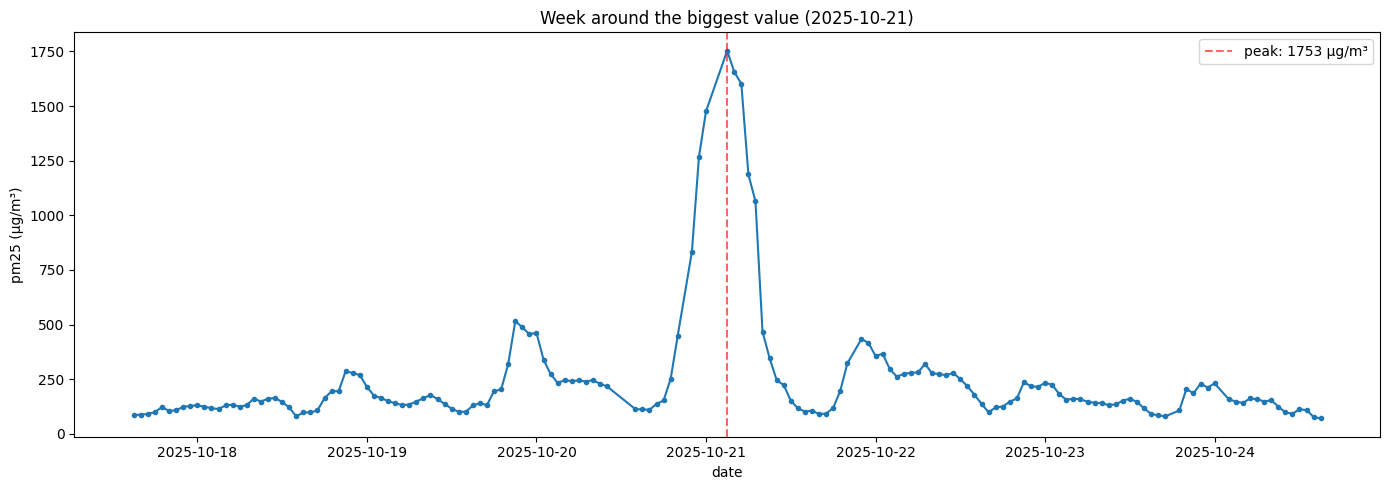

peak: 1753 µg/m³ at 2025-10-21 03:00:00+05:30


In [24]:
# Find when the single biggest hourly value happened, then take a +/- 3.5
# day window around it so the peak sits in the middle of a one-week zoom.
peak_time = hourly.idxmax()
peak_value = hourly.max()
window = hourly[peak_time - pd.Timedelta(days=3.5): peak_time + pd.Timedelta(days=3.5)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(window.index, window.values, marker="o", markersize=3)
ax.axvline(peak_time, color="red", linestyle="--", alpha=0.6, label=f"peak: {peak_value:.0f} µg/m³")
ax.set_xlabel("date")
ax.set_ylabel("pm25 (µg/m³)")
ax.set_title(f"Week around the biggest value ({peak_time.date()})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"peak: {peak_value:.0f} µg/m³ at {peak_time}")

### 2c — Missing hours and missing days: random, or in blocks?

Two different questions here:

1. **How much is missing overall?** Compare the `hourly` series (one row per
   hour that has data) against the full expected range of hours from the
   first to the last timestamp — the difference is the missing hours.
2. **Is it scattered or clustered?** A handful of isolated missing hours
   spread across the year is very different from one 10-day outage, even if
   the total count is similar. We group consecutive missing hours into
   "blocks" and look at the size distribution: many size-1 blocks means
   scattered noise; a few huge blocks means real outages.

We also check whole missing **days** (a calendar day with zero pm25 rows at
all) separately, since that's what the ticket background table asks about
directly.

In [25]:
# The full hour-by-hour range we'd expect, given the first and last hour we
# actually have. Any hour in this range that isn't in `hourly` is missing.
full_range = pd.date_range(hourly.index.min(), hourly.index.max(), freq="h", tz=hourly.index.tz)
missing_hours = full_range.difference(hourly.index)

print(f"total hours in span: {len(full_range)}")
print(f"missing hours: {len(missing_hours)} ({len(missing_hours) / len(full_range):.1%})")

# Group the missing hours into consecutive blocks. A gap of exactly 1 hour
# between two missing timestamps means they're part of the same outage; any
# bigger gap starts a new block. cumsum() on "is this a new block?" gives
# each row a block id.
gap_hours = missing_hours.to_series().diff().dt.total_seconds().div(3600).fillna(1)
block_id = (gap_hours != 1).cumsum()
block_sizes = missing_hours.to_series().groupby(block_id).size()

print(f"\nmissing hours form {len(block_sizes)} separate blocks")
print(f"single-hour blocks (isolated gaps): {(block_sizes == 1).sum()}")
print("10 largest blocks (hours missing in a row):")
block_sizes.sort_values(ascending=False).head(10)

total hours in span: 13680
missing hours: 1515 (11.1%)

missing hours form 315 separate blocks
single-hour blocks (isolated gaps): 178
10 largest blocks (hours missing in a row):


143    241
7       61
242     52
17      44
273     37
0       35
34      35
291     32
155     26
239     24
dtype: int64

total days in span: 571
fully missing days: 17
[datetime.date(2025, 3, 2), datetime.date(2025, 4, 10), datetime.date(2025, 4, 29), datetime.date(2025, 6, 15), datetime.date(2026, 1, 11), datetime.date(2026, 1, 12), datetime.date(2026, 1, 13), datetime.date(2026, 1, 14), datetime.date(2026, 1, 15), datetime.date(2026, 1, 16), datetime.date(2026, 1, 17), datetime.date(2026, 1, 18), datetime.date(2026, 1, 19), datetime.date(2026, 6, 21), datetime.date(2026, 6, 24), datetime.date(2026, 8, 8), datetime.date(2026, 8, 28)]


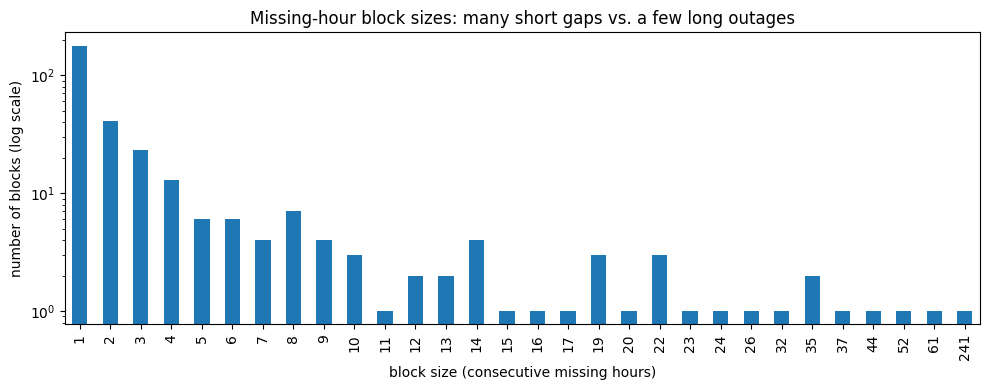

In [26]:
# A calendar day is "fully missing" if pm25_raw has zero rows for it at all
# (not just low coverage — genuinely nothing).
days_present = set(pm25_raw["day"].dt.date)
full_days = pd.date_range(pm25_raw["day"].min(), pm25_raw["day"].max(), freq="D")
missing_days = [d.date() for d in full_days if d.date() not in days_present]

print(f"total days in span: {len(full_days)}")
print(f"fully missing days: {len(missing_days)}")
print(missing_days)

# Bar chart: block size (x) vs how many blocks have that size (y), on a log
# y-axis so both the pile of 1-hour gaps and the rare huge outages are
# visible on the same chart.
fig, ax = plt.subplots(figsize=(10, 4))
block_sizes.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("block size (consecutive missing hours)")
ax.set_ylabel("number of blocks (log scale)")
ax.set_yscale("log")
ax.set_title("Missing-hour block sizes: many short gaps vs. a few long outages")
plt.tight_layout()
plt.show()

### 2d — The invalid days from DAF-05: spread out, or clustered?

`daily_17.csv` already has a `valid` column from earlier work (DAF-05/06):
a day is `False` there for some coverage-based reason (see `hours` — the
count of hourly values that went into that day's mean). This step doesn't
re-derive that logic; it just asks the ticket's question about the *existing*
flag: are the invalid days spread evenly across the year, or clumped into
specific bad stretches/months?

We reuse `daily` (already loaded in Step 1) — count invalid days per month,
and look at the gap in days between one invalid day and the next: lots of
1-day gaps means invalid days cluster back-to-back; large, varied gaps mean
they're scattered.

invalid days: 83 / 571 (14.5%)

invalid days per month:
date
2025-03     4
2025-04    12
2025-05     2
2025-06     5
2025-07     4
2025-08     3
2025-10     2
2025-11     1
2025-12     2
2026-01    10
2026-02     7
2026-03     3
2026-04     1
2026-05     5
2026-06     5
2026-07     2
2026-08    11
2026-09     4
Freq: M, Name: count, dtype: int64


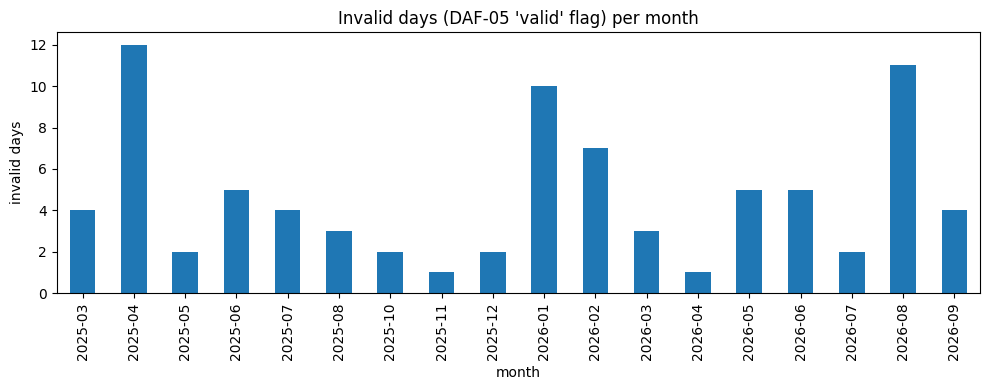

In [27]:
invalid = daily[daily["valid"] == False].copy()

print(f"invalid days: {len(invalid)} / {len(daily)} ({len(invalid) / len(daily):.1%})")

# Count invalid days per calendar month, to see which months are worst.
invalid_by_month = (
    invalid["date"].dt.tz_localize(None).dt.to_period("M").value_counts().sort_index()
)
print("\ninvalid days per month:")
print(invalid_by_month)

fig, ax = plt.subplots(figsize=(10, 4))
invalid_by_month.plot(kind="bar", ax=ax)
ax.set_xlabel("month")
ax.set_ylabel("invalid days")
ax.set_title("Invalid days (DAF-05 'valid' flag) per month")
plt.tight_layout()
plt.show()

In [28]:
# Gap in days between one invalid day and the next invalid day. A gap of 1
# means they're literally back-to-back (clustered); bigger gaps mean the
# invalid days are scattered through otherwise-good stretches.
invalid_sorted = invalid.sort_values("date")
gap_days = invalid_sorted["date"].diff().dt.days

print("gap sizes between consecutive invalid days (in days):")
print(gap_days.value_counts().sort_index())

back_to_back = (gap_days == 1).sum()
print(f"\n{back_to_back} of {len(invalid) - 1} gaps are exactly 1 day (back-to-back)")

gap sizes between consecutive invalid days (in days):
date
1.0     36
2.0      8
3.0      5
4.0      1
5.0      1
6.0      4
7.0      3
8.0      3
9.0      2
10.0     1
12.0     3
13.0     1
14.0     2
17.0     2
18.0     2
19.0     2
20.0     1
24.0     2
26.0     1
53.0     1
54.0     1
Name: count, dtype: int64

36 of 82 gaps are exactly 1 day (back-to-back)
